# Size Normalization and Rebuy-Up Behavior

This notebook tests whether size can be normalized into standard age buckets, and if customers rebuy similar items in larger sizes as children grow.

## 1. Hypothesis and Setup

**Hypothesis:** Size transitions are systematic enough to justify size-aware recommendations or replenishment logic.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Columns to Inspect:**
- size, item_id, customer_id, updated_date, quantity, category fields

**Plan:**
1. Load data lazily using Polars.
2. Explore the raw `size` column distribution.
3. Parse size labels into standardized age-in-years buckets.
4. Measure normalization coverage.
5. Track repeated purchases by customer in the same category.
6. Compute upgrade rate, median time gap, and size transition matrix.
7. Visualize: transition heatmap, rebuy-up bar chart, example customer sequence.
8. Decide whether the signal is strong enough to keep.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../..")
TRANSACTION_FILE = DATA_DIR / "transaction_full_2025.parquet"
ITEMS_FILE = DATA_DIR / "items.parquet"

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Data

In [2]:
transactions = (
    pl.scan_parquet(TRANSACTION_FILE)
    .select(["customer_id", "item_id", "updated_date", "quantity"])
)

items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(["item_id", "size", "category_l1", "category_l2", "category_l3"])
    .filter(pl.col("size").is_not_null())
)

joined = (
    transactions
    .join(items, on="item_id", how="inner")
    .with_columns(
        pl.col("updated_date").dt.truncate("1d").alias("basket_date")
    )
)

print("Lazy data pipeline prepared.")

Lazy data pipeline prepared.


## 3. Explore Raw Size Distribution

Before normalizing, let's understand the raw `size` column: how many unique values exist and what the top values are.

Total unique raw size labels: 97

Top 20 raw size values by item count:
shape: (20, 2)
┌────────────────┬────────────┐
│ size           ┆ item_count │
│ ---            ┆ ---        │
│ str            ┆ u32        │
╞════════════════╪════════════╡
│ Không xác định ┆ 27880      │
│ 0-3M           ┆ 255        │
│ 6-9M           ┆ 209        │
│ 1Y             ┆ 201        │
│ 9 tháng        ┆ 111        │
│ …              ┆ …          │
│ 2Y             ┆ 37         │
│ 9M             ┆ 29         │
│ 18-24M         ┆ 28         │
│ 12-18M         ┆ 25         │
│ 7-8 tuổi       ┆ 22         │
└────────────────┴────────────┘


C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_25948\3392338063.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x="item_count", y="size", palette="coolwarm")


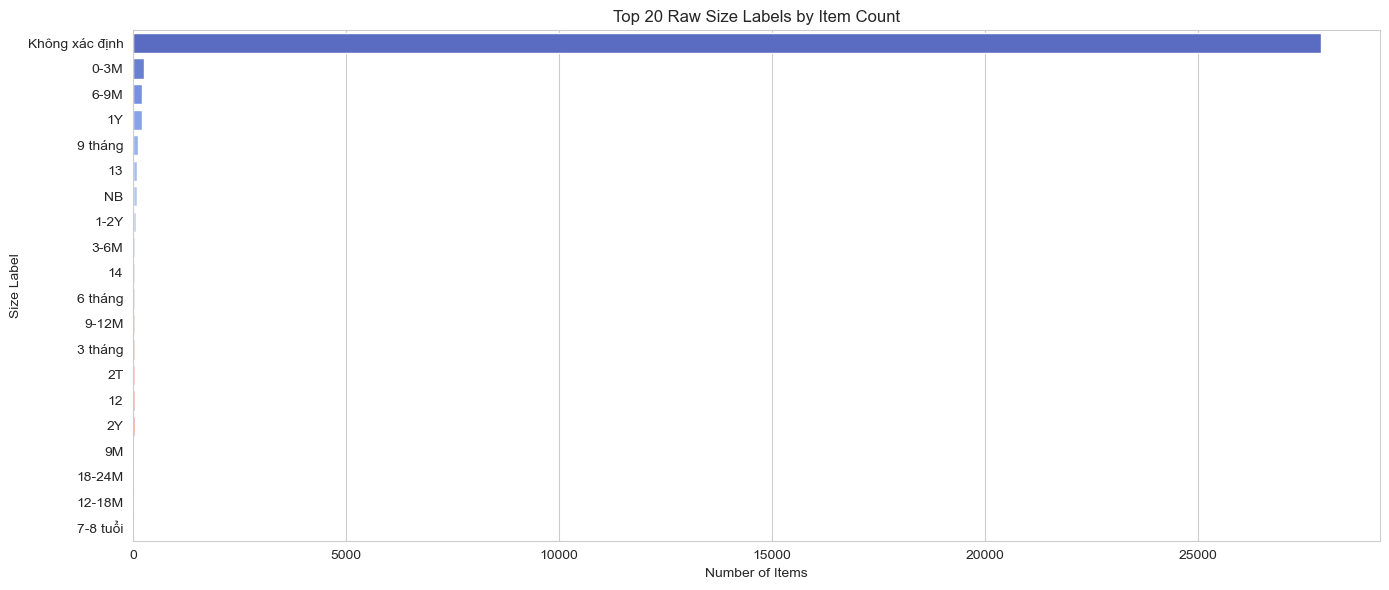

In [3]:
# Explore raw size distribution from items.parquet
raw_sizes = (
    pl.scan_parquet(ITEMS_FILE)
    .select(["item_id", "size"])
    .filter(pl.col("size").is_not_null())
    .group_by("size")
    .agg(pl.len().alias("item_count"))
    .sort("item_count", descending=True)
).collect()

print(f"Total unique raw size labels: {len(raw_sizes)}")
print("\nTop 20 raw size values by item count:")
print(raw_sizes.head(20))

# Bar chart of top 20 raw sizes
top20 = raw_sizes.head(20).to_pandas()
plt.figure(figsize=(14, 6))
sns.barplot(data=top20, x="item_count", y="size", palette="coolwarm")
plt.title("Top 20 Raw Size Labels by Item Count")
plt.xlabel("Number of Items")
plt.ylabel("Size Label")
plt.tight_layout()
plt.show()

## 4. Size Normalization

We use the `standardize_age` function (from `size_to_age.py`) to map raw size labels into numeric age-in-years values.

Rules:
- Dimension sizes (e.g. `24*28cm`) → 0.5 (accessories, average age)
- Adult/mom sizes (e.g. `B85`) → `"Adult"` → filtered out
- Special codes: `S17` → 1.0, `110` → 5.0
- `Không xác định` (unknown) → `None` → filtered out
- Diaper sizes: NB/SS/Sơ sinh → 0, S → 0.25, M → 0.6, L → 1.2, XL → 2.0, XXL → 3.5
- Ranges (e.g. `0-3M`, `1-2Y`) → midpoint, converted to years
- Month units (`9M`, `6 tháng`) → divide by 12
- Year units (`2Y`, `3T`, `1 tuổi`) → direct year value
- Pure numbers > 6 → treat as months; ≤ 6 → treat as years
- Anything else → `"Check tay"` → filtered out

In [4]:
def standardize_age(text):
    """Map raw size label to numeric age in years. Returns float, 'Adult', 'None', or 'Check tay'."""
    raw_text = str(text).strip()
    clean_text = raw_text.lower()

    # 1. Dimension sizes (accessories)
    if re.search(r'(\*|x\d|cm)', clean_text):
        return 0.5

    # 2. Adult/mom sizes
    if re.search(r'\bb\d{2}\b', clean_text):
        return None  # filter out

    # 3. Special codes
    if 's17' in clean_text:
        return 1.0
    if '110' in clean_text:
        return 5.0

    # 4. Unknown
    if 'không xác định' in clean_text or not clean_text:
        return None

    # 5. Diaper/clothing standard sizes
    diaper_map = {
        r'\bnb\b': 0.0, r'\bss\b': 0.0, r'\bsơ sinh\b': 0.0,
        r'\bs\b': 0.25, r'\bm\b': 0.6, r'\bl\b': 1.2,
        r'\bxl\b': 2.0, r'\bxxl\b': 3.5
    }
    for pattern, val in diaper_map.items():
        if re.search(pattern, clean_text):
            return val

    # 6. Range patterns (e.g. 0-3M, 1-2 tuổi, 18-24M)
    range_match = re.search(r'(\d+\.?\d*)\s*-\s*(\d+\.?\d*)', clean_text)
    if range_match:
        s, e = float(range_match.group(1)), float(range_match.group(2))
        avg = (s + e) / 2
        if any(x in clean_text for x in ['m', 'tháng']):
            return round(avg / 12, 3)
        return avg

    # 7. Single number + unit
    m_match = re.search(r'(\d+\.?\d*)\s*(m|tháng)', clean_text)
    if m_match:
        return round(float(m_match.group(1)) / 12, 3)

    y_match = re.search(r'(\d+\.?\d*)\s*(y|t|tuổi)', clean_text)
    if y_match:
        return float(y_match.group(1))

    # 8. Pure number: > 6 → months, ≤ 6 → years
    pure_num = re.search(r'^(\d+)$', clean_text)
    if pure_num:
        val = float(pure_num.group(1))
        if val > 6:
            return round(val / 12, 3)
        return val

    return None  # unclassifiable


def normalize_size(df: pl.LazyFrame) -> pl.LazyFrame:
    """Apply standardize_age to the size column, cast to Float64, filter out nulls."""
    return (
        df
        .with_columns(
            pl.col('size')
              .map_elements(standardize_age, return_dtype=pl.Float64)
              .alias('norm_size')
        )
        .filter(pl.col('norm_size').is_not_null())
    )


normalized_data = normalize_size(joined)

sizes_count = (
    normalized_data
    .group_by("norm_size")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
).collect()

print("Top normalized sizes (age in years):")
print(sizes_count.head(15))

Top normalized sizes (age in years):
shape: (15, 2)
┌───────────┬───────┐
│ norm_size ┆ count │
│ ---       ┆ ---   │
│ f64       ┆ u32   │
╞═══════════╪═══════╡
│ 3.5       ┆ 98930 │
│ 1.2       ┆ 94483 │
│ 0.6       ┆ 76992 │
│ 0.25      ┆ 48525 │
│ 1.0       ┆ 38167 │
│ …         ┆ …     │
│ 2.0       ┆ 7410  │
│ 1.083     ┆ 7179  │
│ 1.167     ┆ 6898  │
│ 3.0       ┆ 5632  │
│ 1.25      ┆ 5090  │
└───────────┴───────┘


## 5. Normalization Coverage

How many transaction rows survive normalization? This tells us if the signal is broad enough.

Total joined rows (with non-null size): 37,684,782
Rows after normalization (valid numeric age): 493,804
Normalization coverage: 1.3%
Rows filtered out: 37,190,978 (98.7%)


C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_25948\3342496207.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_sizes.head(20), x="count", y="norm_size", palette="viridis")


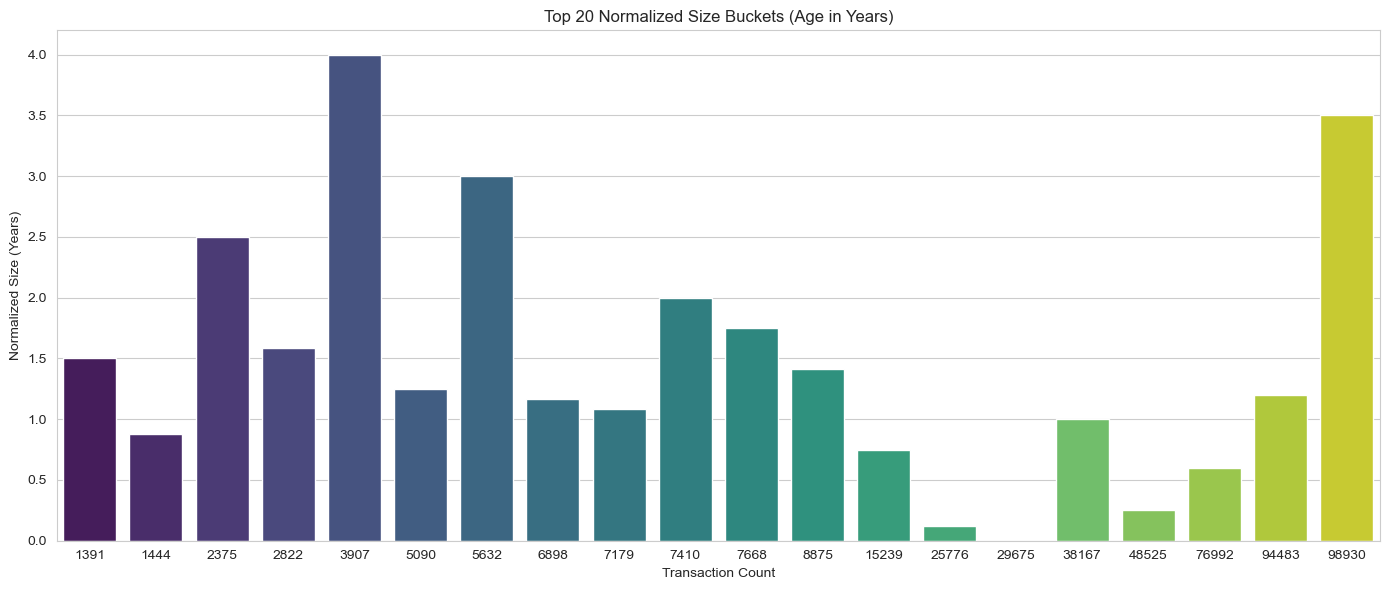

In [5]:
total_joined = joined.select(pl.len()).collect().item()
total_normalized = normalized_data.select(pl.len()).collect().item()
coverage = total_normalized / total_joined * 100 if total_joined > 0 else 0

print(f"Total joined rows (with non-null size): {total_joined:,}")
print(f"Rows after normalization (valid numeric age): {total_normalized:,}")
print(f"Normalization coverage: {coverage:.1f}%")
print(f"Rows filtered out: {total_joined - total_normalized:,} ({100 - coverage:.1f}%)")

# Distribution of normalized sizes
pd_sizes = sizes_count.to_pandas()
plt.figure(figsize=(14, 6))
sns.barplot(data=pd_sizes.head(20), x="count", y="norm_size", palette="viridis")
plt.title("Top 20 Normalized Size Buckets (Age in Years)")
plt.xlabel("Transaction Count")
plt.ylabel("Normalized Size (Years)")
plt.tight_layout()
plt.show()

## 6. Size Transition Analysis

For each customer × category_l2, sort purchases by date and compute the transition from current size to next size.

In [6]:
# Build customer purchase sequences within the same category_l2
customer_seq = (
    normalized_data
    .sort(["customer_id", "category_l2", "basket_date"])
    .with_columns([
        pl.col("norm_size").shift(-1).over(["customer_id", "category_l2"]).alias("next_size"),
        pl.col("basket_date").shift(-1).over(["customer_id", "category_l2"]).alias("next_date")
    ])
    .filter(pl.col("next_size").is_not_null())
)

# Transition matrix
transitions = (
    customer_seq
    .group_by(["norm_size", "next_size"])
    .agg(pl.len().alias("transition_count"))
    .sort("transition_count", descending=True)
).collect()

print("Top 15 Size Transitions (current → next):")
print(transitions.head(15))

Top 15 Size Transitions (current → next):
shape: (15, 3)
┌───────────┬───────────┬──────────────────┐
│ norm_size ┆ next_size ┆ transition_count │
│ ---       ┆ ---       ┆ ---              │
│ f64       ┆ f64       ┆ u32              │
╞═══════════╪═══════════╪══════════════════╡
│ 3.5       ┆ 3.5       ┆ 60096            │
│ 1.2       ┆ 1.2       ┆ 45882            │
│ 0.6       ┆ 0.6       ┆ 36180            │
│ 0.25      ┆ 0.25      ┆ 16900            │
│ 0.0       ┆ 0.0       ┆ 6736             │
│ …         ┆ …         ┆ …                │
│ 0.75      ┆ 1.0       ┆ 1120             │
│ 1.2       ┆ 0.6       ┆ 959              │
│ 0.25      ┆ 3.5       ┆ 855              │
│ 2.0       ┆ 2.0       ┆ 789              │
│ 1.0       ┆ 2.0       ┆ 743              │
└───────────┴───────────┴──────────────────┘


## 7. Upgrade Rate and Time Gap Statistics

**Key metrics:**
- `upgrade_rate = upgrade_sequences / repeat_sequences`
- Median time gap between sequential purchases in the same category

In [7]:
# Add time gap column
customer_seq_with_gap = customer_seq.with_columns(
    (pl.col("next_date") - pl.col("basket_date")).dt.total_days().alias("time_gap_days")
)

# Total repeat sequences
repeat_sequences = customer_seq_with_gap.select(pl.len()).collect().item()

# Upgrade sequences (next_size > norm_size)
upgrade_df = customer_seq_with_gap.filter(pl.col("next_size") > pl.col("norm_size")).collect()
upgrade_sequences = len(upgrade_df)

# Downgrade sequences (next_size < norm_size)
downgrade_df = customer_seq_with_gap.filter(pl.col("next_size") < pl.col("norm_size")).collect()
downgrade_sequences = len(downgrade_df)

# Same-size sequences
same_size_sequences = repeat_sequences - upgrade_sequences - downgrade_sequences

upgrade_rate = upgrade_sequences / repeat_sequences if repeat_sequences > 0 else 0
downgrade_rate = downgrade_sequences / repeat_sequences if repeat_sequences > 0 else 0
same_rate = same_size_sequences / repeat_sequences if repeat_sequences > 0 else 0

# Median time gap
median_gap = customer_seq_with_gap.select(pl.col("time_gap_days").median()).collect().item()

print(f"Total Repeat Sequences: {repeat_sequences:,}")
print(f"  Upgrade (size up):   {upgrade_sequences:,} ({upgrade_rate:.2%})")
print(f"  Same size:           {same_size_sequences:,} ({same_rate:.2%})")
print(f"  Downgrade (size down): {downgrade_sequences:,} ({downgrade_rate:.2%})")
print(f"\nMedian time gap between repeated purchases: {median_gap} days")

Total Repeat Sequences: 199,228
  Upgrade (size up):   13,382 (6.72%)
  Same size:           180,736 (90.72%)
  Downgrade (size down): 5,110 (2.56%)

Median time gap between repeated purchases: 19.0 days


## 8. Rebuy-Up Frequency by Category

Top 10 Categories for Rebuy-Up:
shape: (10, 2)
┌────────────────────────────┬───────────────┐
│ category_l2                ┆ upgrade_count │
│ ---                        ┆ ---           │
│ str                        ┆ u32           │
╞════════════════════════════╪═══════════════╡
│ Huggies                    ┆ 4116          │
│ Takato                     ┆ 3995          │
│ Thời trang bé trai         ┆ 2070          │
│ Thời trang bé gái          ┆ 1708          │
│ Giày tập đi                ┆ 1019          │
│ Quần áo & Phụ kiện sơ sinh ┆ 261           │
│ Giày dép 1-3Y              ┆ 131           │
│ Modal kháng khuẩn          ┆ 33            │
│ Cơ cấu hàng cũ             ┆ 32            │
│ Thời trang đông            ┆ 13            │
└────────────────────────────┴───────────────┘


C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_25948\1606230276.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_up, x="upgrade_count", y="category_l2", palette="viridis")


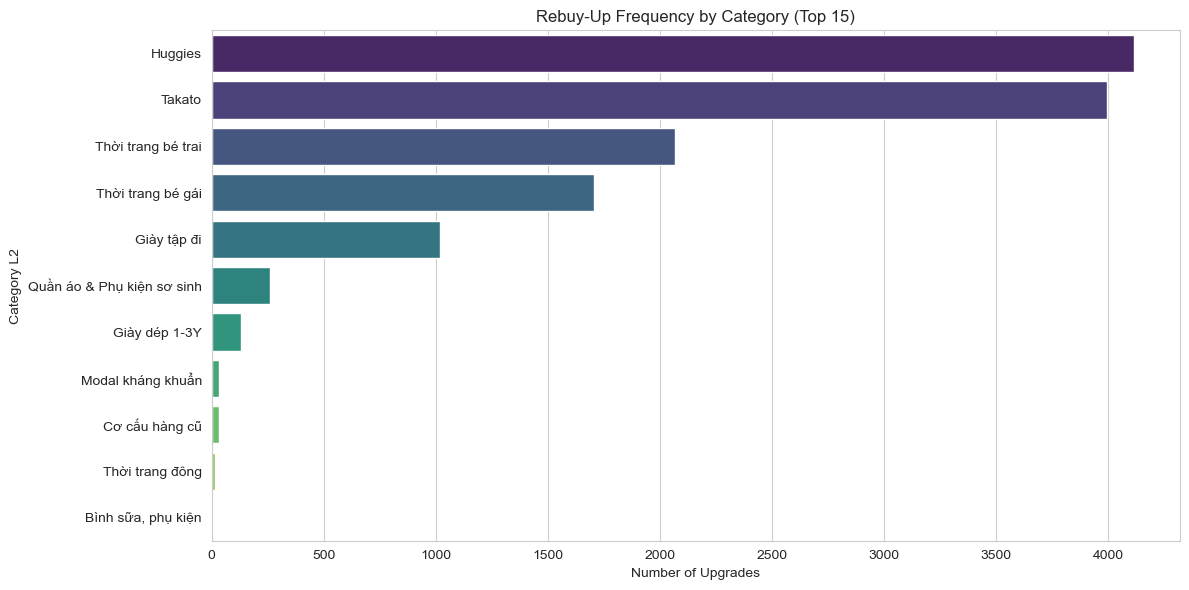

In [8]:
# Rebuy-up frequency by category_l2
upgrade_by_cat = (
    customer_seq_with_gap
    .filter(pl.col("next_size") > pl.col("norm_size"))
    .group_by("category_l2")
    .agg(pl.len().alias("upgrade_count"))
    .sort("upgrade_count", descending=True)
).collect()

print("Top 10 Categories for Rebuy-Up:")
print(upgrade_by_cat.head(10))

if len(upgrade_by_cat) > 0:
    pd_up = upgrade_by_cat.head(15).to_pandas()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=pd_up, x="upgrade_count", y="category_l2", palette="viridis")
    plt.title("Rebuy-Up Frequency by Category (Top 15)")
    plt.xlabel("Number of Upgrades")
    plt.ylabel("Category L2")
    plt.tight_layout()
    plt.show()

## 9. Size Transition Heatmap

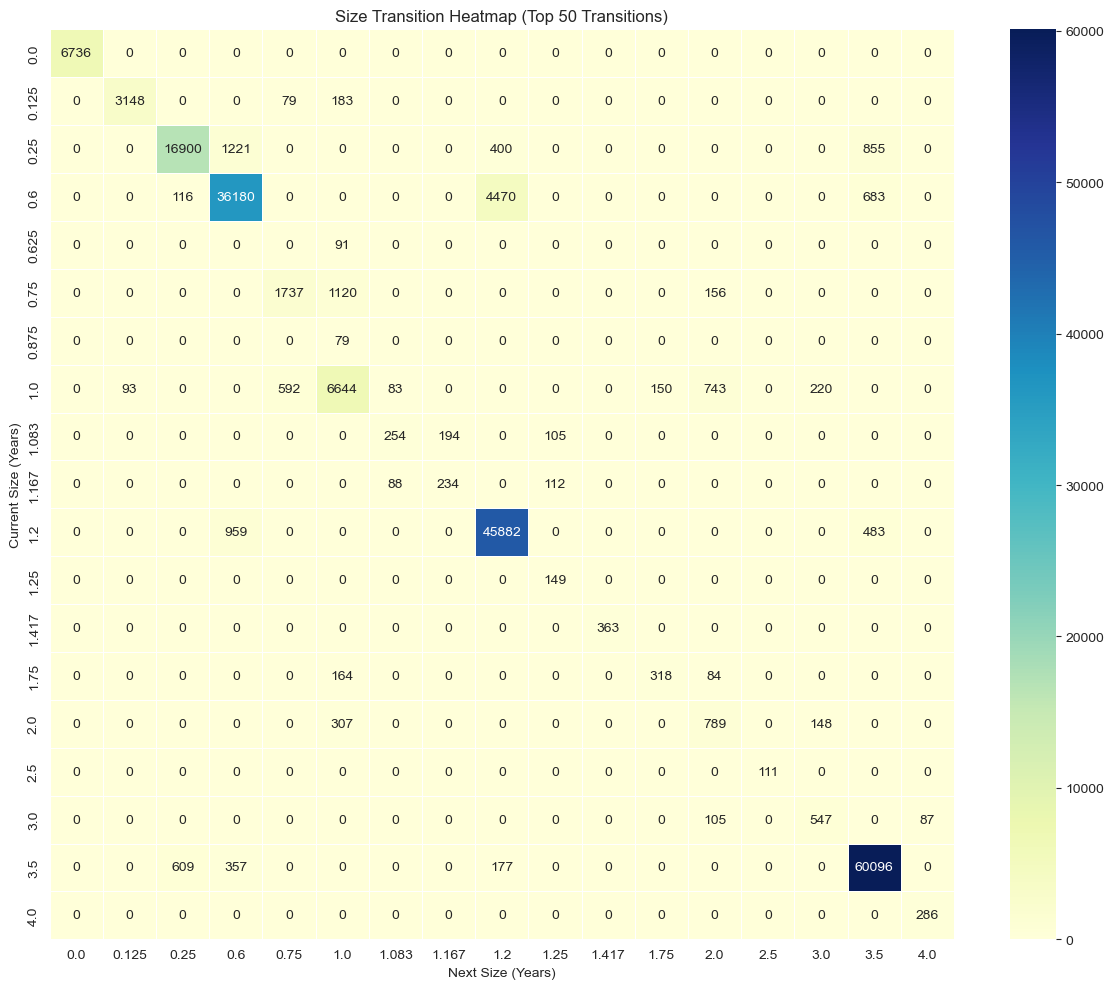

In [9]:
if len(transitions) > 0:
    pivot_transitions = (
        transitions.head(50)
        .pivot(values="transition_count", index="norm_size", on="next_size")
        .fill_null(0)
    )
    pd_transitions = pivot_transitions.to_pandas().set_index("norm_size")

    # Sort index and columns numerically
    pd_transitions = pd_transitions.sort_index()
    sorted_cols = sorted(pd_transitions.columns, key=lambda x: float(x))
    pd_transitions = pd_transitions[sorted_cols]

    plt.figure(figsize=(12, 10))
    sns.heatmap(pd_transitions, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
    plt.title("Size Transition Heatmap (Top 50 Transitions)")
    plt.ylabel("Current Size (Years)")
    plt.xlabel("Next Size (Years)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for transition heatmap.")

## 10. Example Customer Sequence Plot

Pick a few customers who have the most repeat purchases in a single category and visualize their size progression over time.

Top 5 customer-category pairs by purchase count:
shape: (5, 3)
┌─────────────┬─────────────┬────────────────┐
│ customer_id ┆ category_l2 ┆ purchase_count │
│ ---         ┆ ---         ┆ ---            │
│ i32         ┆ str         ┆ u32            │
╞═════════════╪═════════════╪════════════════╡
│ 7034935     ┆ Huggies     ┆ 46             │
│ 2761654     ┆ Huggies     ┆ 40             │
│ 6645404     ┆ Huggies     ┆ 38             │
│ 3978621     ┆ Huggies     ┆ 37             │
│ 4106724     ┆ Huggies     ┆ 34             │
└─────────────┴─────────────┴────────────────┘


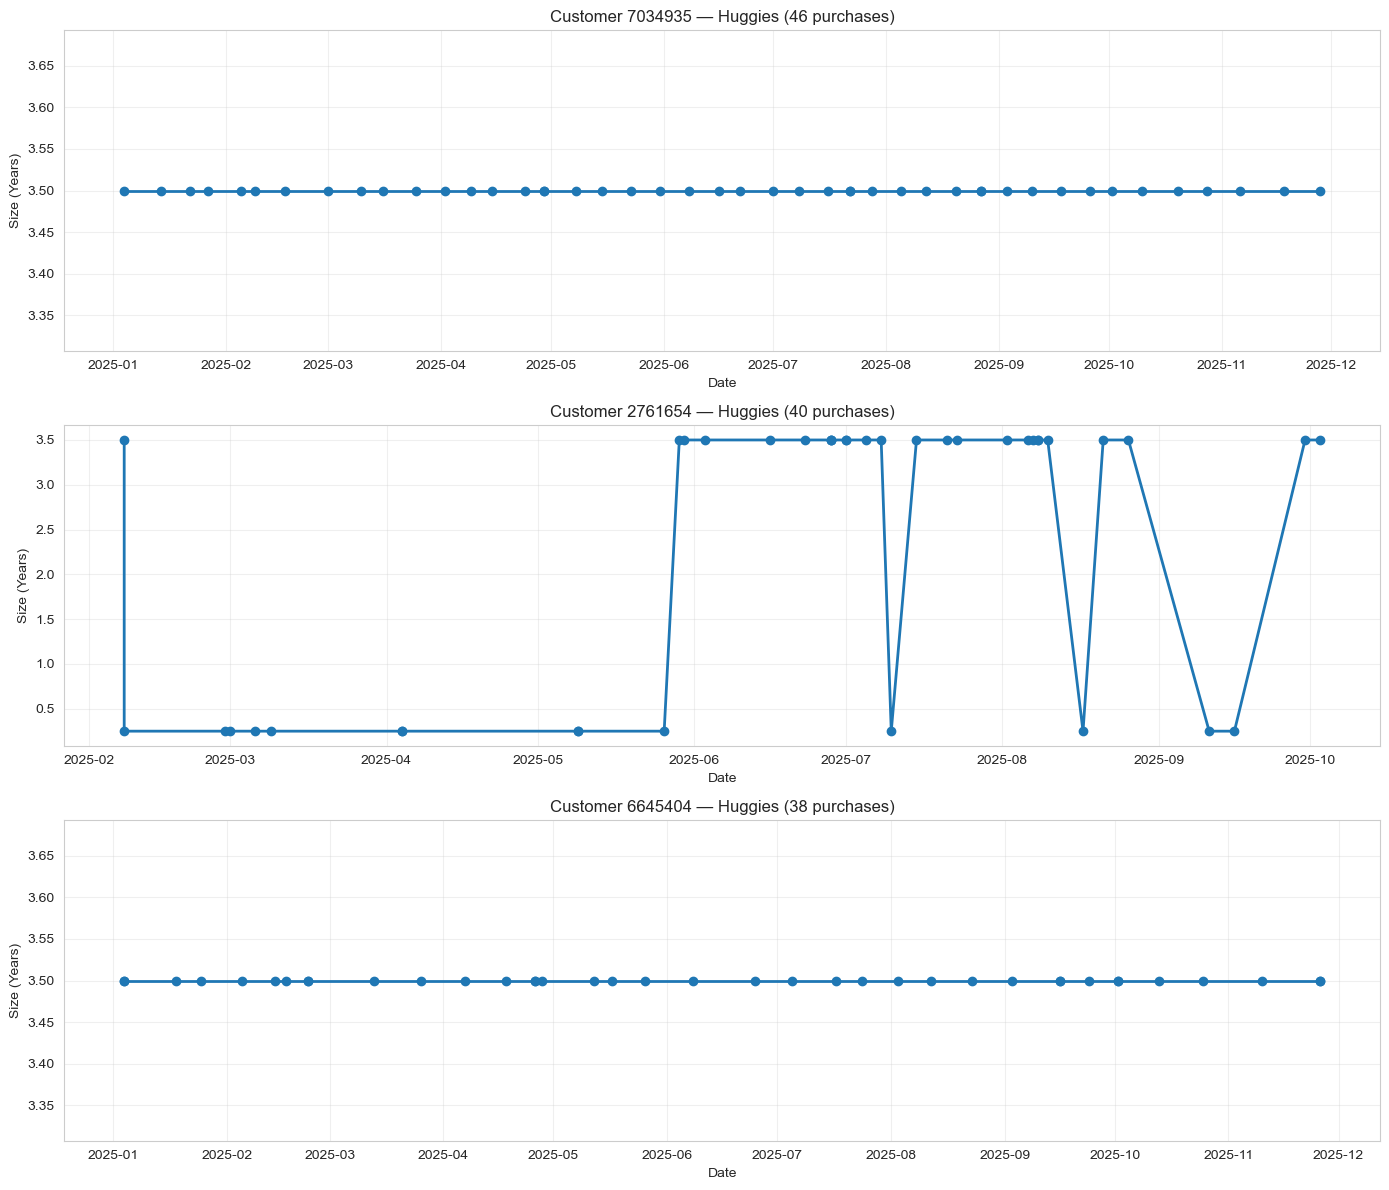

In [10]:
# Find customers with the most repeat purchases in one category
top_customers = (
    normalized_data
    .group_by(["customer_id", "category_l2"])
    .agg(pl.len().alias("purchase_count"))
    .filter(pl.col("purchase_count") >= 5)  # at least 5 purchases
    .sort("purchase_count", descending=True)
    .head(5)
).collect()

print("Top 5 customer-category pairs by purchase count:")
print(top_customers)

if len(top_customers) > 0:
    fig, axes = plt.subplots(min(len(top_customers), 3), 1, figsize=(14, 4 * min(len(top_customers), 3)))
    if min(len(top_customers), 3) == 1:
        axes = [axes]

    for i, row in enumerate(top_customers.head(3).iter_rows(named=True)):
        cid = row["customer_id"]
        cat = row["category_l2"]

        seq = (
            normalized_data
            .filter(
                (pl.col("customer_id") == cid) & (pl.col("category_l2") == cat)
            )
            .sort("basket_date")
            .select(["basket_date", "norm_size"])
        ).collect().to_pandas()

        ax = axes[i]
        ax.plot(seq["basket_date"], seq["norm_size"], marker="o", linewidth=2)
        ax.set_title(f"Customer {cid} — {cat} ({len(seq)} purchases)")
        ax.set_xlabel("Date")
        ax.set_ylabel("Size (Years)")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for example customer sequences.")

## 11. Conclusion and Decision

**Decision Rule:** Keep the idea if size transitions are systematic enough to justify size-aware recommendations or replenishment logic.

### Summary of Findings

| Metric | Value |
|--------|-------|
| Total joined rows (with non-null size) | 37,684,782 |
| Rows after normalization (valid numeric age) | 493,804 |
| **Normalization coverage** | **1.3%** |
| Total repeat sequences | 199,228 |
| **Upgrade rate (size up)** | **6.72%** (13,382 sequences) |
| **Same-size rate** | **90.72%** (180,736 sequences) |
| **Downgrade rate (size down)** | **2.56%** (5,110 sequences) |
| **Median time gap** | **19.0 days** |

### Top Categories for Rebuy-Up

| Category | Upgrade Count |
|----------|---------------|
| Huggies | 4,116 |
| Takato | 3,995 |
| Thoi trang be trai | 2,070 |
| Thoi trang be gai | 1,708 |
| Giay tap di | 1,019 |

### Interpretation

1. **Normalization coverage is very low (1.3%).**
   Out of ~37.7M transaction rows with a non-null size, only ~494K survive normalization. This is because the vast majority of items carry `Khong xac dinh` (27,880 unique items), adult/bra sizes, or other labels that cannot be mapped to a child age. The analyzable signal is therefore limited to a narrow subset of the catalog -- primarily diapers (Huggies, Takato) and children clothing.

2. **Same-size rate dominates at 90.72%.**
   Customers overwhelmingly rebuy the **same size** in the same category. The transition heatmap confirms this: the strongest cells lie on the diagonal (e.g., 3.5 -> 3.5 with 60,096 transitions, 1.2 -> 1.2 with 45,882, 0.6 -> 0.6 with 36,180). This is the replenishment pattern -- parents stock up on the same diaper or clothing size repeatedly.

3. **Upgrade rate is only 6.72%.**
   True size-up transitions (e.g., S -> M, M -> L) are relatively rare. While categories like Huggies (4,116) and Takato (3,995) show meaningful upgrade counts, these are driven by the natural progression of diaper sizes as children grow, not by a broad cross-category pattern.

4. **Downgrade rate is very low (2.56%).**
   Size-down transitions are uncommon, which is expected -- children grow, they do not shrink. The low downgrade rate validates the normalization logic (ages are mapped correctly in ascending order).

5. **Median time gap is 19 days.**
   Customers tend to return to buy the same category roughly every 2-3 weeks. This is a strong signal for **replenishment reminders** -- we can predict when a customer is likely to need their next purchase.

### Decision

**Verdict: KEEP -- with a narrowed scope.**

- **Size-up recommendations**: The upgrade rate (6.72%) is too low to build a general-purpose size-up recommendation engine across all categories. However, for **diaper brands** (Huggies, Takato) and **children clothing** (Thoi trang be trai/gai), the signal is concentrated enough to be actionable.

- **Replenishment logic**: The 90.72% same-size rate and 19-day median gap provide a **strong foundation for replenishment workflows**. We can build a system that reminds customers to rebuy the same product at a predicted interval.

- **Caveat**: The 1.3% normalization coverage means this analysis only applies to a small slice of the overall catalog. Improving size label standardization upstream (reducing `Khong xac dinh` items) would dramatically expand the addressable signal.